Problema 2: Una aseguradora tiene datos de 120 clientes con su edad y el costo mensual de su póliza. Requieren modelar cómo aumenta el costo con la edad para ajustar sus tarifas.

Lo que debe hacer el código:

    Cargar los datos demográficos y de costos
    Verificar la relación lineal mediante un gráfico inicial
    Entrenar el modelo de regresión y extraer sus parámetros
    Calcular intervalos de confianza para las predicciones
    Crear una visualización que muestre: Puntos con los datos reales y línea de regresión
    Generar una tabla con predicciones para edades clave (30, 40, 50, 60 años)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import scipy.stats as stats

In [2]:
df = pd.read_csv('EdadSeguros.csv')

In [3]:
print(df.head())

   Edad   Costo
0     18     22
1     22     24
2     23     55
3     25     27
4     27     85


In [5]:
df.columns = df.columns.str.strip()
X = df[['Edad']]
y = df['Costo']

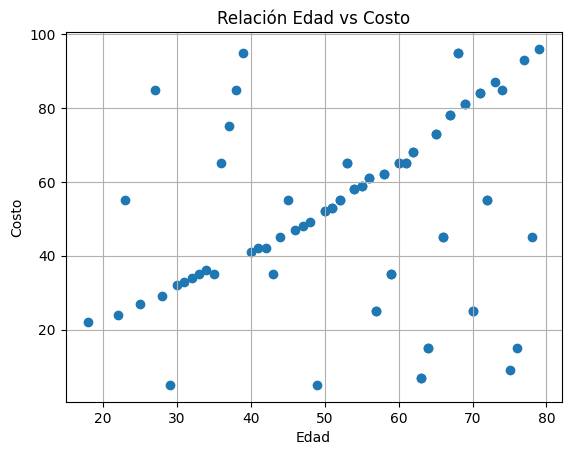

In [6]:
plt.scatter(X, y)
plt.title("Relación Edad vs Costo")
plt.xlabel("Edad")
plt.ylabel("Costo")
plt.grid()
plt.show()

In [7]:
modelo = LinearRegression()
modelo.fit(X, y)

LinearRegression()

In [8]:
m = modelo.coef_[0]
b = modelo.intercept_

print(f"Pendiente: {m}")
print(f"Intercepto: {b}")

Pendiente: 0.4607049329271551
Intercepto: 27.399609855165416


In [9]:
y_pred = modelo.predict(X)

In [14]:
n = len(X)
mean_x = np.mean(X)
t = stats.t.ppf(0.975, df=n-2)

residuos = y - y_pred
s_err = np.sqrt(np.sum(residuos**2)/(n-2))

confianza = t * s_err * np.sqrt(1/n + (X - mean_x)**2 / np.sum((X - mean_x)**2))

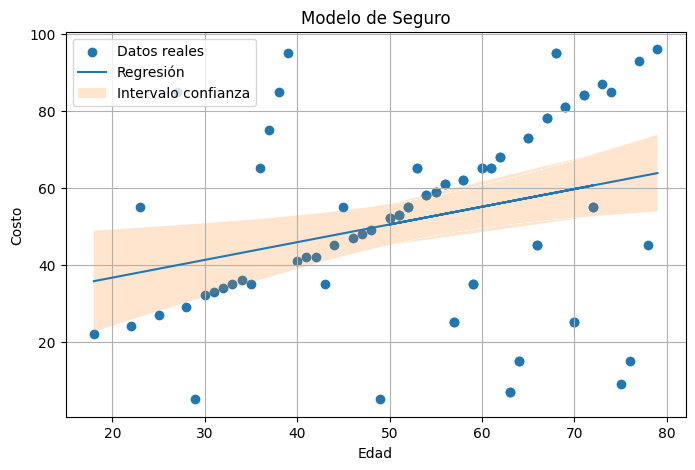

In [16]:
plt.figure(figsize=(8,5))
plt.scatter(X, y, label="Datos reales")
plt.plot(X, y_pred, label="Regresión")
plt.fill_between(X.values.flatten(),
                 (y_pred - confianza.values.flatten()),
                 (y_pred + confianza.values.flatten()),
                 alpha=0.2, label="Intervalo confianza")

plt.xlabel("Edad")
plt.ylabel("Costo")
plt.title("Modelo de Seguro")
plt.legend()
plt.grid()
plt.show()

In [18]:
edades = pd.DataFrame({'Edad':[30,40,50,60]})
predicciones = modelo.predict(edades)
tabla = edades.copy()
tabla['Costo estimado'] = predicciones

print(tabla)

   Edad  Costo estimado
0    30       41.220758
1    40       45.827807
2    50       50.434857
3    60       55.041906
